In [14]:
import pandas as pd
data=pd.read_csv('Data/Train.csv')

In [15]:

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 836982 entries, 0 to 836981
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_session      836982 non-null  str    
 1   total_carts       836982 non-null  int64  
 2   total_removes     836982 non-null  int64  
 3   total_views       836982 non-null  int64  
 4   session_duration  836982 non-null  float64
 5   avg_price         836982 non-null  float64
 6   max_price         836982 non-null  float64
 7   unique_products   836982 non-null  int64  
 8   unique_brands     836982 non-null  int64  
 9   is_purchased      836982 non-null  int64  
dtypes: float64(3), int64(6), str(1)
memory usage: 92.6 MB


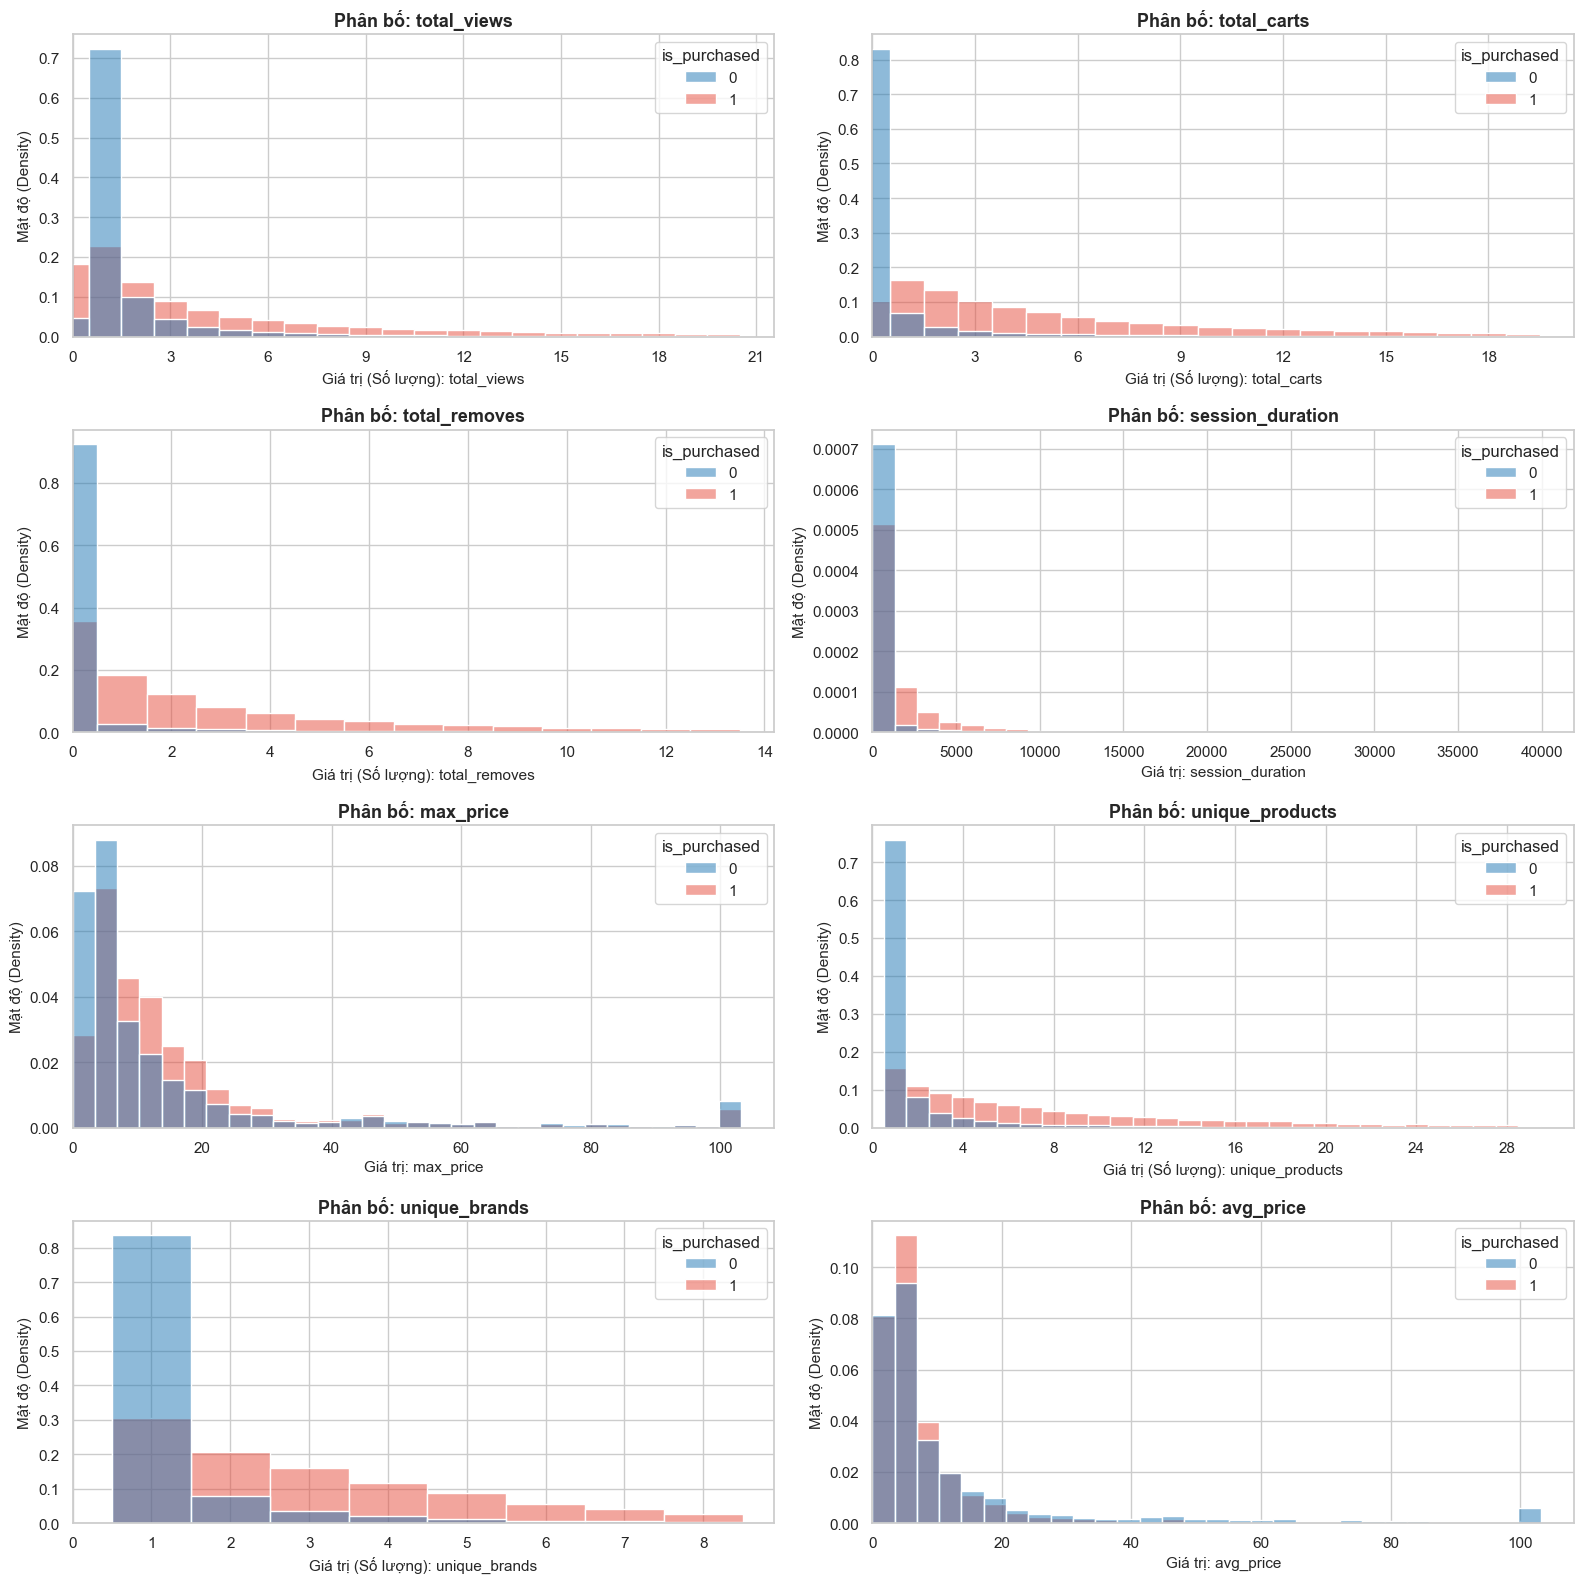

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore') # Tắt cảnh báo

# Cài đặt style
sns.set_theme(style="whitegrid")

# ĐÃ SỬA: Xóa 'unique_products' bị lặp ở cuối danh sách. Hiện tại có đúng 8 biến.
features_to_plot = [
    'total_views', 'total_carts', 'total_removes', 
    'session_duration', 'max_price', 'unique_products', 
    'unique_brands', 'avg_price'
]

# Danh sách các biến chắc chắn là SỐ NGUYÊN (Discrete)
int_features = ['total_views', 'total_carts', 'total_removes', 'unique_products', 'unique_brands'] # Bổ sung unique_brands

# 1. ĐÃ SỬA: Nâng lên 4 hàng, 2 cột (Kích thước 16x16 cho 8 ô)
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(16, 16))
axes = axes.flatten() # Làm phẳng để dùng vòng lặp cho dễ

# Chạy vòng lặp vẽ từng ô
for i, col in enumerate(features_to_plot):
    
    # Lọc bỏ 1% râu ngoại lệ để hình không bị kéo dài
    q_limit = data[col].quantile(0.99)
    plot_data = data[data[col] <= q_limit] if q_limit > 0 else data
    
    # Kiểm tra xem biến đang vẽ có phải là số nguyên không
    is_integer_feature = col in int_features
    
    # 2. VẼ BIỂU ĐỒ HISTOGRAM VÀO TỪNG Ô
    sns.histplot(
        data=plot_data,          
        x=col, 
        hue='is_purchased', 
        stat='density',      
        common_norm=False,   
        palette=['#1f77b4', '#e74c3c'], # Đổi màu đỏ cho dễ nhìn sự tương phản
        alpha=0.5,           
        edgecolor='white',
        discrete=is_integer_feature, 
        bins=None if is_integer_feature else 30,
        ax=axes[i]  
    )
    
    # Ép trục X bắt đầu từ 0 cho từng ô
    axes[i].set_xlim(left=0)
    
    # 3. ÉP TRỤC X CHỈ HIỆN SỐ NGUYÊN (Cho các ô thuộc biến đếm)
    if is_integer_feature:
        axes[i].xaxis.set_major_locator(MaxNLocator(integer=True))
    
    # 4. TRANG TRÍ TIÊU ĐỀ, TRỤC CHO TỪNG Ô
    axes[i].set_title(f'Phân bố: {col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'Giá trị (Số lượng): {col}' if is_integer_feature else f'Giá trị: {col}', fontsize=11)
    axes[i].set_ylabel('Mật độ (Density)', fontsize=11)

# TÍNH NĂNG BỔ SUNG: Tự động ẩn các ô trống (nếu số biến ít hơn số ô tạo ra)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 5. CĂN CHỈNH VÀ XUẤT ẢNH LỚN
plt.tight_layout()
plt.savefig('feature_histograms_combined.png', dpi=300) 
plt.show()

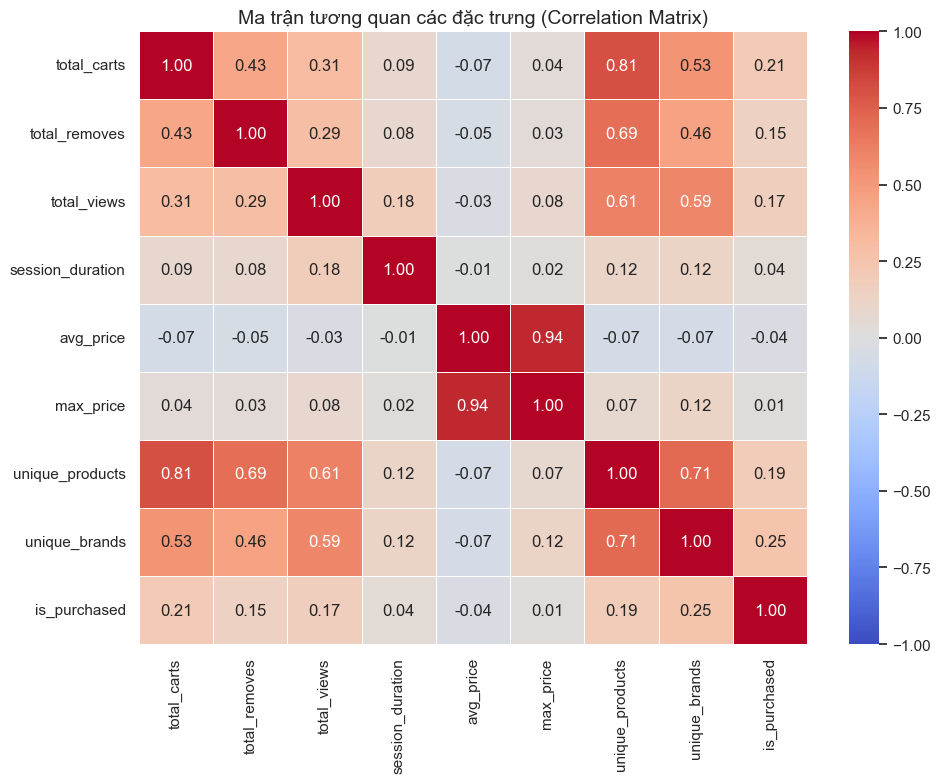

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chọn các cột dạng số (loại bỏ cột user_session)
# Bạn có thể dùng df.select_dtypes(include=['int64', 'float64'])
numeric_df = data.drop(columns=['user_session'])

# 2. Tính toán ma trận tương quan (mặc định là Pearson)
corr_matrix = numeric_df.corr()

# 3. Vẽ ma trận tương quan
plt.figure(figsize=(10, 8)) # Thiết lập kích thước khung hình

# Sử dụng seaborn heatmap để vẽ
sns.heatmap(corr_matrix, 
            annot=True,       # Hiển thị giá trị tương quan trên từng ô
            cmap='coolwarm',  # Chọn bảng màu (coolwarm hiển thị rõ âm/dương)
            fmt=".2f",        # Làm tròn 2 chữ số thập phân
            linewidths=0.5,   # Độ dày đường viền giữa các ô
            vmin=-1, vmax=1)  # Giới hạn thang màu từ -1 đến 1

# Thêm tiêu đề
plt.title('Ma trận tương quan các đặc trưng (Correlation Matrix)', fontsize=14)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

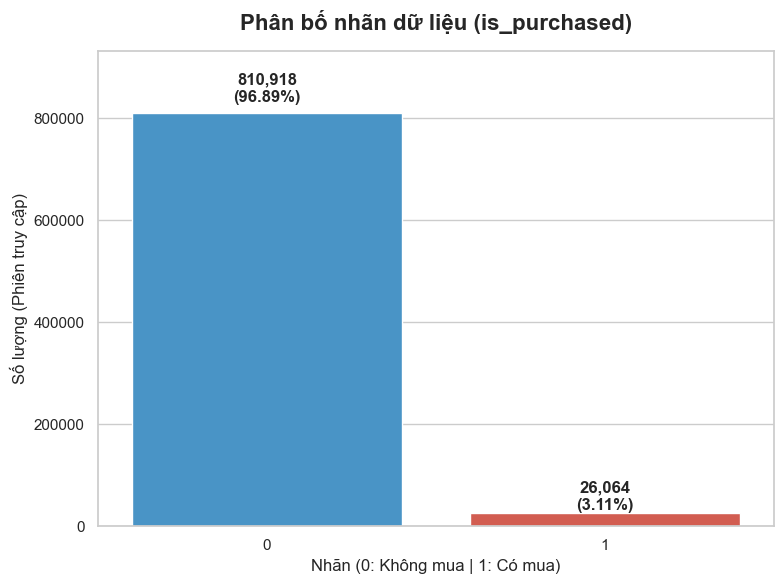

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử DataFrame của bạn đang có tên là 'data'
# data = pd.read_csv('du_lieu_cua_ban.csv')

# 1. Tính toán số lượng và tỷ lệ phần trăm
class_counts = data['is_purchased'].value_counts()
class_percentages = data['is_purchased'].value_counts(normalize=True) * 100

# 2. Thiết lập kích thước biểu đồ
plt.figure(figsize=(8, 6))

# 3. Vẽ biểu đồ cột bằng Seaborn
ax = sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    palette=['#3498db', '#e74c3c'] # Màu xanh cho 0, màu đỏ cho 1
)

# 4. Thêm tiêu đề và nhãn
plt.title('Phân bố nhãn dữ liệu (is_purchased)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Nhãn (0: Không mua | 1: Có mua)', fontsize=12)
plt.ylabel('Số lượng (Phiên truy cập)', fontsize=12)

# 5. Thêm chú thích (Số lượng & Phần trăm) trực tiếp lên từng cột
for i, count in enumerate(class_counts.values):
    # Tính phần trăm tương ứng
    percentage = class_percentages.values[i]
    
    # Hiển thị text trên đầu cột
    ax.text(
        i, count + (count * 0.02), # Vị trí Y (cao hơn đỉnh cột 1 chút)
        f"{count:,}\n({percentage:.2f}%)", # Nội dung: Số lượng \n (Phần trăm)
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

# 6. Điều chỉnh giới hạn trục Y để chữ không bị cắt
plt.ylim(0, class_counts.max() * 1.15)

# 7. Hiển thị
plt.tight_layout()
plt.show()